In [1]:
import pyarrow.feather as feather

tbl = feather.read_table("cosmos_subset.feather", memory_map=True)
df = tbl.to_pandas(ignore_metadata=True)

In [2]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
f=glob('eazy*')
wave1={}
norm_flux1={}
for idx, i in enumerate(f):
    wave, flux = np.loadtxt(i, unpack=True)
    flux *= wave**2. / 3e18
    norm=np.sqrt(np.sum(flux**2))
    norm_flux=flux/norm
    wave1[i]=wave
    norm_flux1[i]=norm_flux
    

In [3]:
wave_grid = np.linspace(1500, 20000, 1000)
norm_flux_interp={}
for idx, i in enumerate(wave1.keys()):
    norm_flux_int = np.interp(wave_grid, wave1[i], norm_flux1[i])
    norm_flux_interp[i]=norm_flux_int

In [4]:
flux_list = []
for name in norm_flux_interp.keys():
    flux_list.append(norm_flux_interp[name])

data_matrix = np.array(flux_list)

from sklearn.decomposition import NMF
model = NMF(4, init='random', random_state=0)
W = model.fit_transform(data_matrix)
H = model.components_

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


# Redshifting PCA components

In [26]:
import numpy as np
from sedpy.observate import load_filters, getSED

fil=['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y','subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484','subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679','subaru_suprimecam_ia738',
 'subaru_suprimecam_ia767','subaru_suprimecam_ip','subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J','vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']

filters=load_filters(fil)

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename, resource_listdir


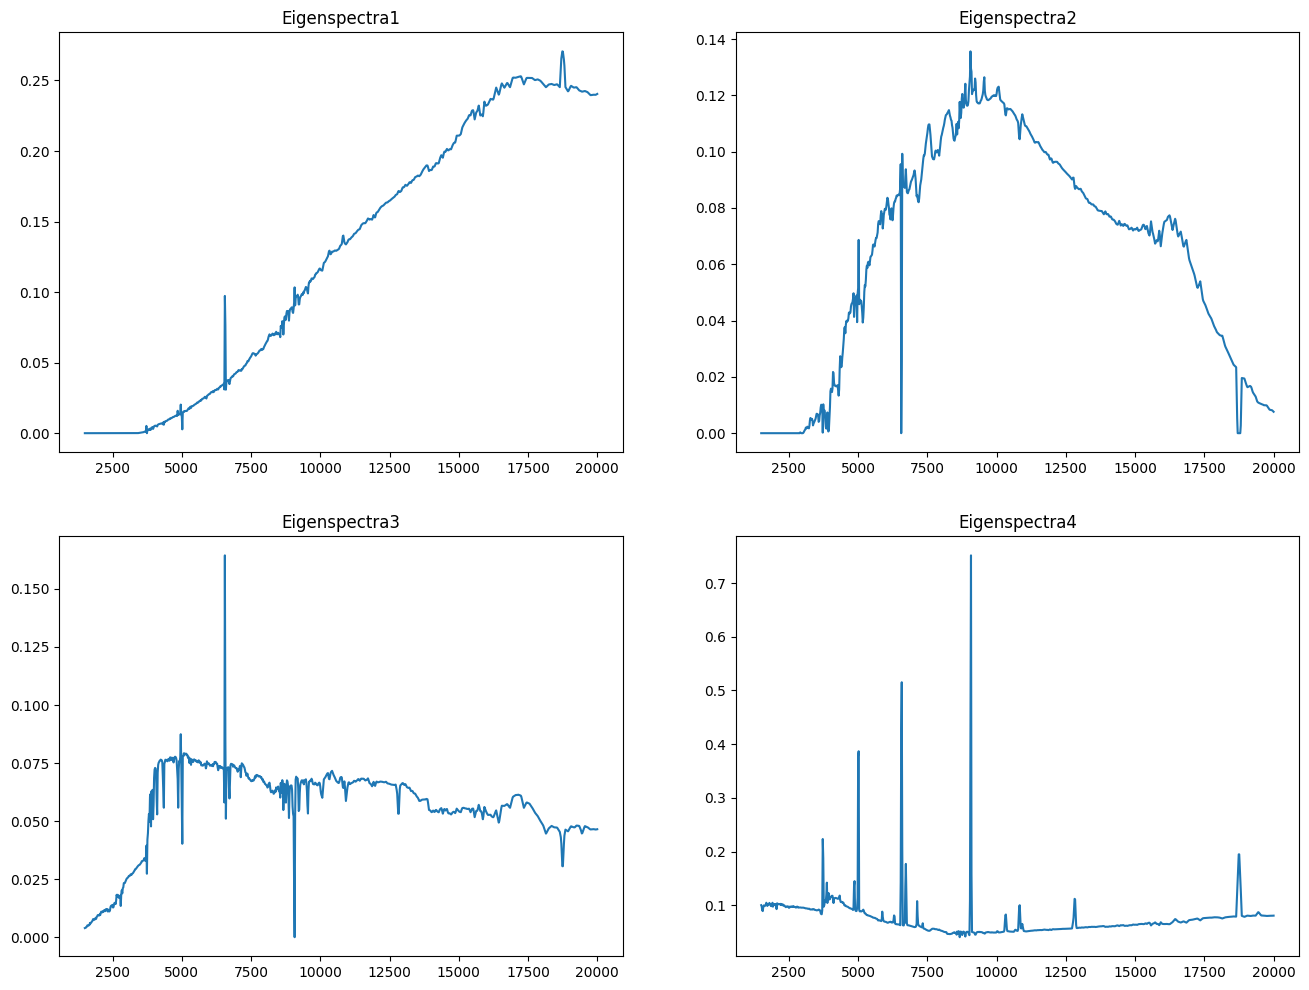

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axs=axes.flatten()
for i in range(len(H)):
    ax = axs[i]
    ax.plot(wave_grid, H[i])
    ax.set_title(f'Eigenspectra{i+1}')

In [28]:
z_grid=np.linspace(0,12,501)
z_grid=z_grid[1:]
z_grid

array([ 0.024,  0.048,  0.072,  0.096,  0.12 ,  0.144,  0.168,  0.192,
        0.216,  0.24 ,  0.264,  0.288,  0.312,  0.336,  0.36 ,  0.384,
        0.408,  0.432,  0.456,  0.48 ,  0.504,  0.528,  0.552,  0.576,
        0.6  ,  0.624,  0.648,  0.672,  0.696,  0.72 ,  0.744,  0.768,
        0.792,  0.816,  0.84 ,  0.864,  0.888,  0.912,  0.936,  0.96 ,
        0.984,  1.008,  1.032,  1.056,  1.08 ,  1.104,  1.128,  1.152,
        1.176,  1.2  ,  1.224,  1.248,  1.272,  1.296,  1.32 ,  1.344,
        1.368,  1.392,  1.416,  1.44 ,  1.464,  1.488,  1.512,  1.536,
        1.56 ,  1.584,  1.608,  1.632,  1.656,  1.68 ,  1.704,  1.728,
        1.752,  1.776,  1.8  ,  1.824,  1.848,  1.872,  1.896,  1.92 ,
        1.944,  1.968,  1.992,  2.016,  2.04 ,  2.064,  2.088,  2.112,
        2.136,  2.16 ,  2.184,  2.208,  2.232,  2.256,  2.28 ,  2.304,
        2.328,  2.352,  2.376,  2.4  ,  2.424,  2.448,  2.472,  2.496,
        2.52 ,  2.544,  2.568,  2.592,  2.616,  2.64 ,  2.664,  2.688,
      

In [29]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)

In [30]:
f_z = {}
wave_z = {}
H = np.asarray(H)
wave_grid = np.asarray(wave_grid)

for z in z_grid:
    wave_z[z] = wave_grid * (1 + z)
    dL = cosmo.luminosity_distance(z).value * 3.086e32  
    denom = (1 + z) * 4 * np.pi * dL**2
    #rest_waves = wave_grid / (1 + z)
    H_interp = np.array([np.interp(wave_grid, wave_grid, H_j)* 3631 * 1e6 for H_j in H])
    f_z[z] = H_interp / denom


In [31]:
pca_f={}
for i in z_grid:
    f=getSED(wave_z[i],f_z[i],filters,linear_flux=True)
    pca_f[i]=f
    

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:484: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10(counts / self.ab_zero_counts)


In [32]:
pca_f[0]=getSED(wave_grid,H,filters,linear_flux=True)* 3631 * 1e6

In [33]:
last_key = list(pca_f.keys())[-1]
last_value = pca_f[last_key]

# 2. Remove the last key-value pair
del pca_f[last_key]

# 3. Create a new dictionary with the last element as first
new_dict = {last_key: last_value}
new_dict.update(pca_f)


In [34]:
pca_f=new_dict

In [35]:
z_grid

array([ 0.024,  0.048,  0.072,  0.096,  0.12 ,  0.144,  0.168,  0.192,
        0.216,  0.24 ,  0.264,  0.288,  0.312,  0.336,  0.36 ,  0.384,
        0.408,  0.432,  0.456,  0.48 ,  0.504,  0.528,  0.552,  0.576,
        0.6  ,  0.624,  0.648,  0.672,  0.696,  0.72 ,  0.744,  0.768,
        0.792,  0.816,  0.84 ,  0.864,  0.888,  0.912,  0.936,  0.96 ,
        0.984,  1.008,  1.032,  1.056,  1.08 ,  1.104,  1.128,  1.152,
        1.176,  1.2  ,  1.224,  1.248,  1.272,  1.296,  1.32 ,  1.344,
        1.368,  1.392,  1.416,  1.44 ,  1.464,  1.488,  1.512,  1.536,
        1.56 ,  1.584,  1.608,  1.632,  1.656,  1.68 ,  1.704,  1.728,
        1.752,  1.776,  1.8  ,  1.824,  1.848,  1.872,  1.896,  1.92 ,
        1.944,  1.968,  1.992,  2.016,  2.04 ,  2.064,  2.088,  2.112,
        2.136,  2.16 ,  2.184,  2.208,  2.232,  2.256,  2.28 ,  2.304,
        2.328,  2.352,  2.376,  2.4  ,  2.424,  2.448,  2.472,  2.496,
        2.52 ,  2.544,  2.568,  2.592,  2.616,  2.64 ,  2.664,  2.688,
      

In [36]:
z_grid1=np.insert(z_grid,0,0)

In [37]:
z_grid1

array([ 0.   ,  0.024,  0.048,  0.072,  0.096,  0.12 ,  0.144,  0.168,
        0.192,  0.216,  0.24 ,  0.264,  0.288,  0.312,  0.336,  0.36 ,
        0.384,  0.408,  0.432,  0.456,  0.48 ,  0.504,  0.528,  0.552,
        0.576,  0.6  ,  0.624,  0.648,  0.672,  0.696,  0.72 ,  0.744,
        0.768,  0.792,  0.816,  0.84 ,  0.864,  0.888,  0.912,  0.936,
        0.96 ,  0.984,  1.008,  1.032,  1.056,  1.08 ,  1.104,  1.128,
        1.152,  1.176,  1.2  ,  1.224,  1.248,  1.272,  1.296,  1.32 ,
        1.344,  1.368,  1.392,  1.416,  1.44 ,  1.464,  1.488,  1.512,
        1.536,  1.56 ,  1.584,  1.608,  1.632,  1.656,  1.68 ,  1.704,
        1.728,  1.752,  1.776,  1.8  ,  1.824,  1.848,  1.872,  1.896,
        1.92 ,  1.944,  1.968,  1.992,  2.016,  2.04 ,  2.064,  2.088,
        2.112,  2.136,  2.16 ,  2.184,  2.208,  2.232,  2.256,  2.28 ,
        2.304,  2.328,  2.352,  2.376,  2.4  ,  2.424,  2.448,  2.472,
        2.496,  2.52 ,  2.544,  2.568,  2.592,  2.616,  2.64 ,  2.664,
      

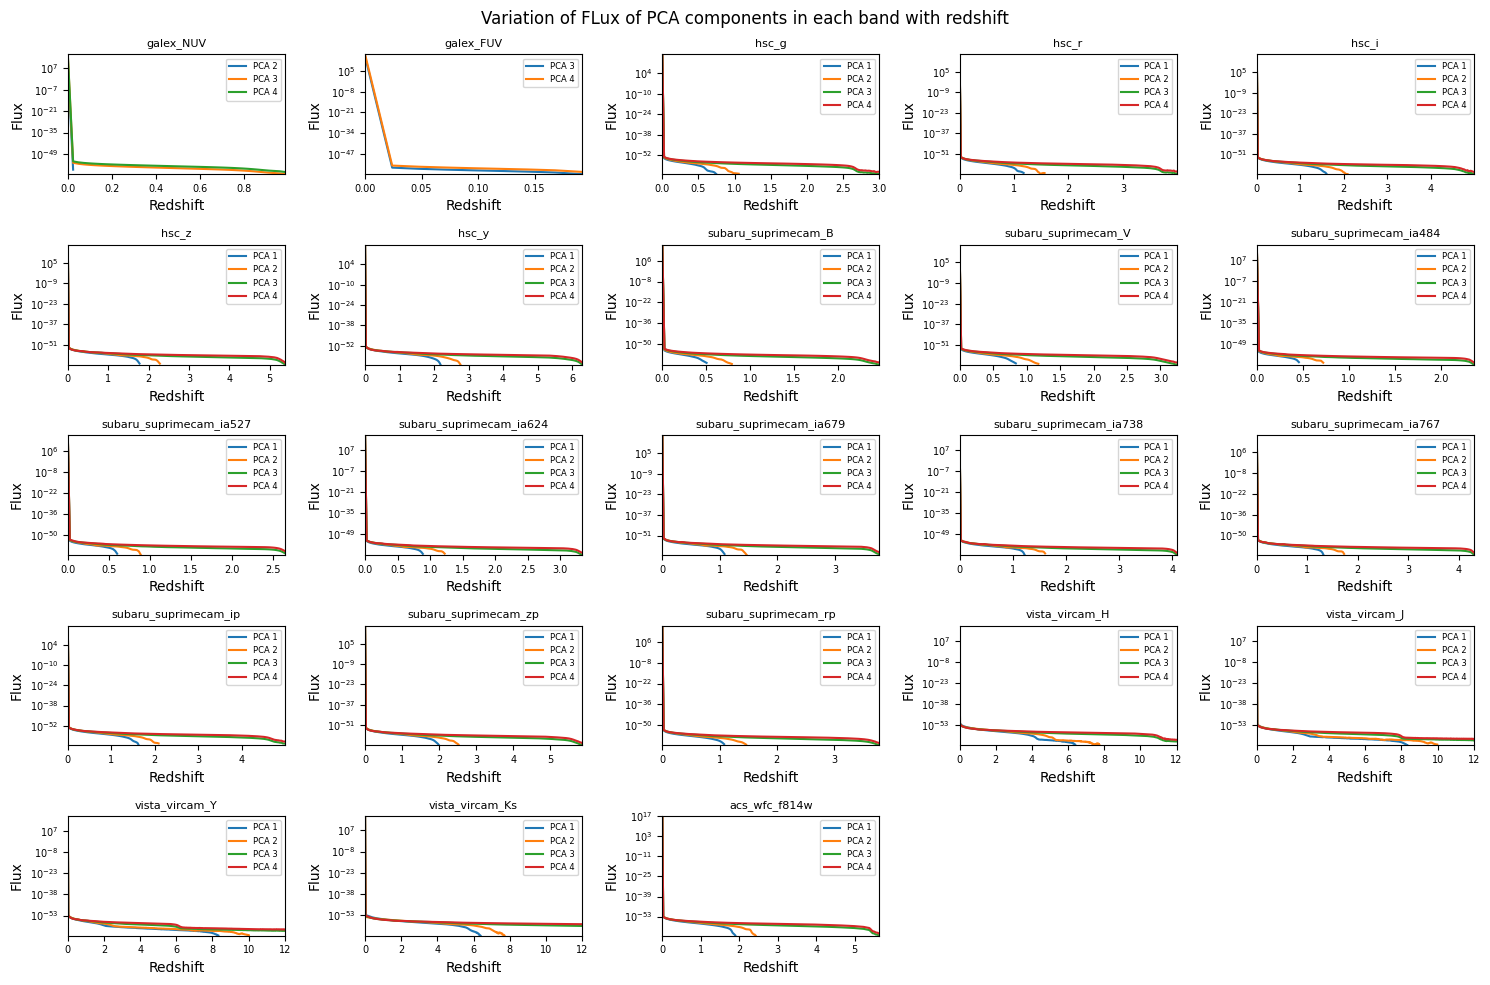

In [344]:
import numpy as np
import matplotlib.pyplot as plt

# Sort redshifts (keys)

# Convert f_z into a stacked array of shape (n_z, 4, 23)
f_all = np.array([pca_f[z] for z in z_grid1])  # shape: (n_z, 4, 23)
f_all = np.nan_to_num(f_all, nan=0.0)

n_pca, n_filters = f_all.shape[1], f_all.shape[2]

fig, axes = plt.subplots(5, 5, figsize=(15, 10), sharex=False, sharey=False)
axes = axes.flatten()

for filt_idx in range(n_filters):
    ax = axes[filt_idx]
    fluxes = f_all[:, :, filt_idx]  # shape (n_z, n_pca)
    
    for comp_idx in range(n_pca):
        flux = fluxes[:, comp_idx]
        
        # mask out regions where flux is zero or negligible
        mask = flux > 0
        if np.sum(mask) == 0:
            continue  # nothing to plot for this component
        
        # only keep valid parts of the curve
        z_valid = np.array(z_grid1)[mask]
        flux_valid = flux[mask]

        ax.plot(z_valid, flux_valid, label=f'PCA {comp_idx+1}')

    ax.set_title(f'{fil[filt_idx]}', fontsize=8)
    ax.set_xlabel('Redshift')
    ax.set_ylabel('Flux')
    ax.set_yscale('log')
    ax.tick_params(labelsize=7)
    ax.relim()
    ax.autoscale(enable=True, axis='both', tight=True)
    ax.legend(fontsize=6)

# Hide unused subplots
for ax in axes[n_filters:]:
    ax.axis('off')

# Legend only on the first plot

plt.suptitle('Variation of FLux of PCA components in each band with redshift')
plt.tight_layout()
plt.show()




In [345]:
f_all.shape

(501, 4, 23)

In [346]:
np.save('pcaflux_w_redshift.npy',f_all)

# Mock Photometry

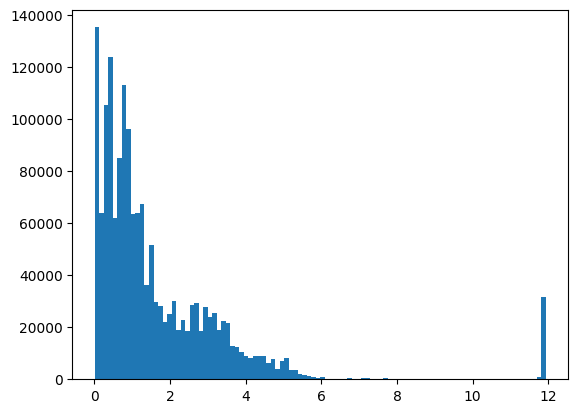

In [5]:
plt.hist(df['ez_z_phot'].tolist(),bins=100)
plt.show()

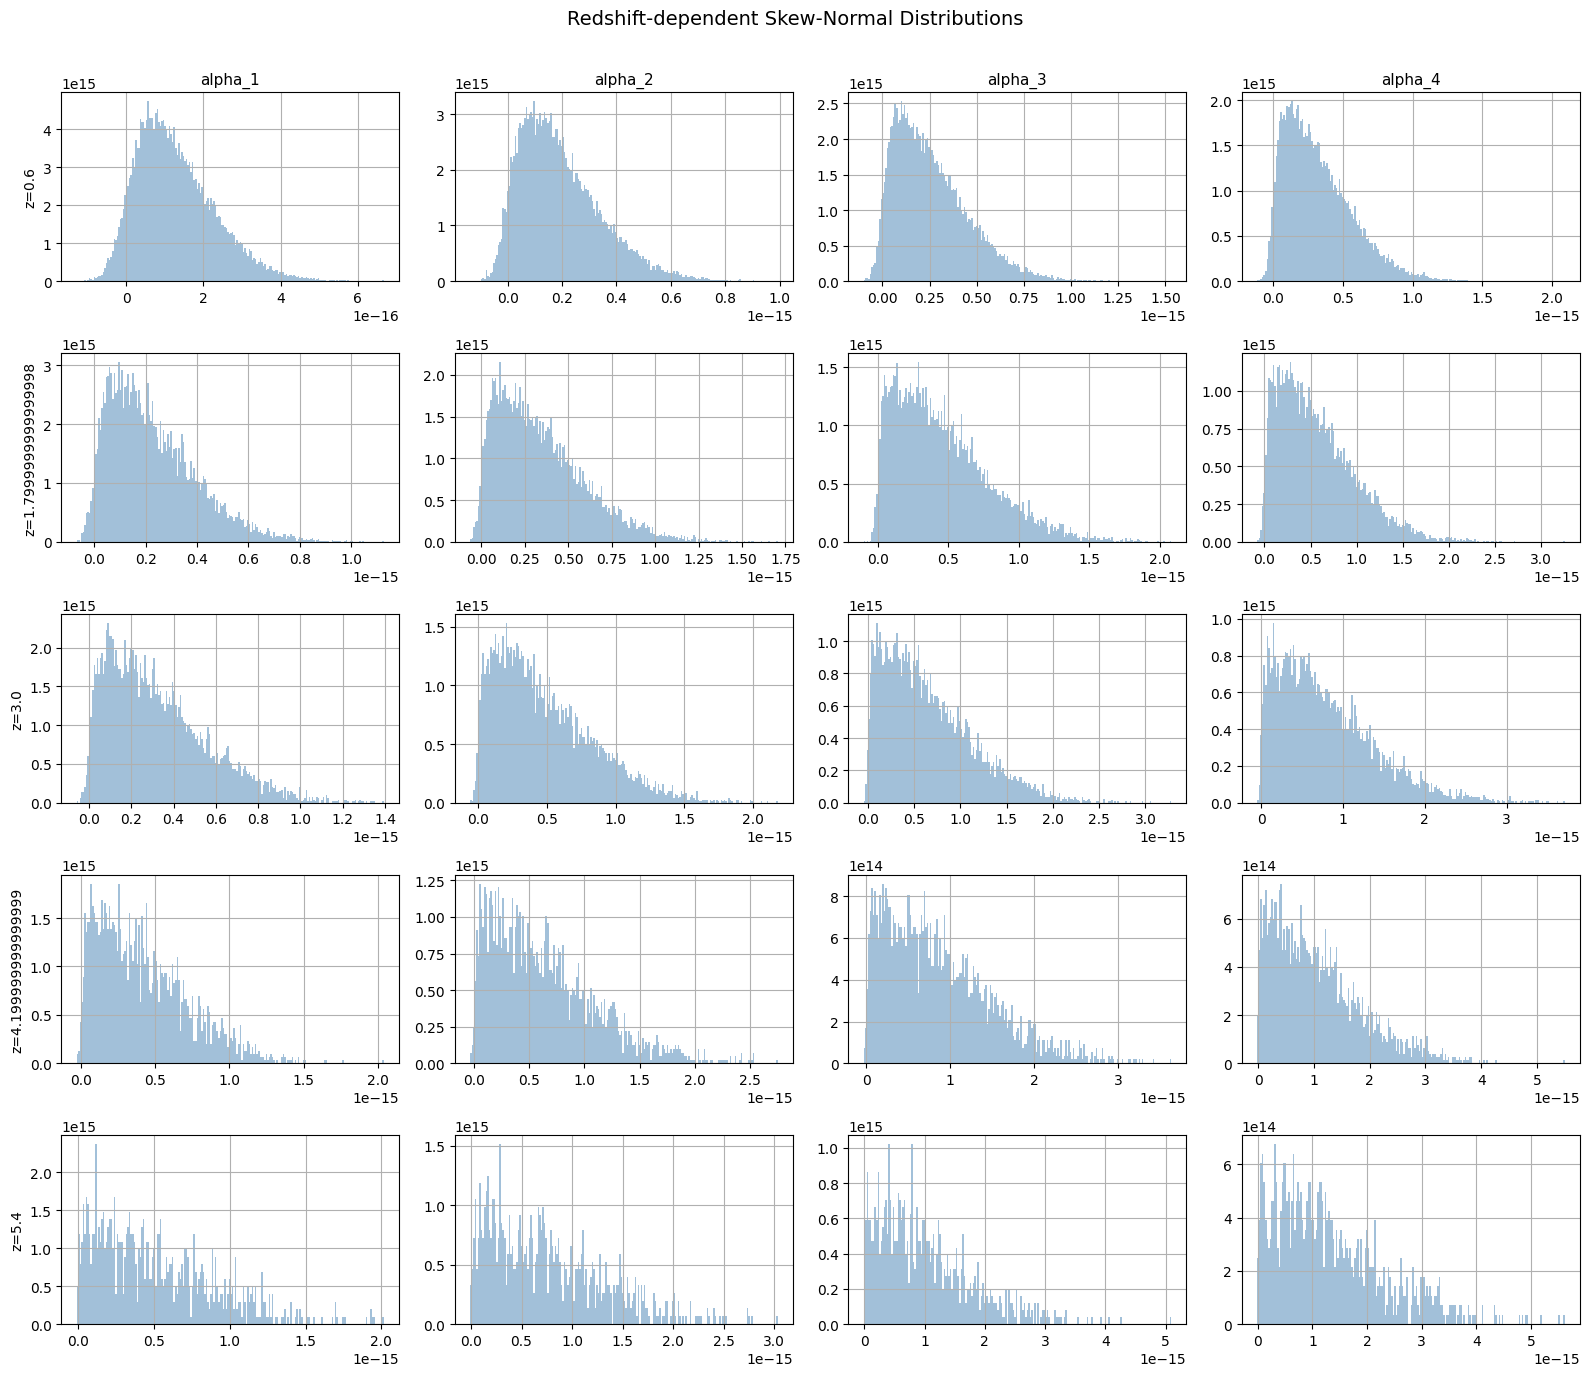

In [45]:
import numpy as np
from scipy.stats import skewnorm
import matplotlib.pyplot as plt

names = ['alpha_1', 'alpha_2', 'alpha_3', 'alpha_4']
x_min, x_max = -1e-15, 1e-15

# Create figure: 7 redshifts × 4 coefficients
# your empirical redshift histogram
counts, edges = np.histogram(df['ez_z_phot'].tolist(), bins=5, range=(0,6))
p_z = counts / counts.sum()
z_centers = 0.5*(edges[1:]+edges[:-1])
fig, axes = plt.subplots(len(z_centers), len(names), figsize=(16, 14))
s=[1,1.5,2,2.5]
rng = np.random.default_rng(42)

for i,(z, p) in enumerate(zip(z_centers, p_z)):
    n = int(50000 * p)       # proportional to observed density
    a = 2*(1+z)**2
    loc = 2e-18*(1+z)
    scale = 1e-16*(1+z)
    for j, (nm,sc) in enumerate(zip(names,s)):
        ax = axes[i, j]
        x = skewnorm.rvs(sc*a, loc=loc, scale=sc*scale, size=n, random_state=rng)
        x = x[(x >= x_min)]
        ax.hist(x, bins=200, density=True, alpha=0.5, color="steelblue")
        ax.grid()

        if i == 0:
            ax.set_title(f"{nm}", fontsize=11)
        if j == 0:
            ax.set_ylabel(f"z={z}", fontsize=10)

plt.suptitle("Redshift-dependent Skew-Normal Distributions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

        


In [206]:
import numpy as np
from scipy.stats import skewnorm

def generate_alpha_coeffs(z, n_gal, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    # Individual skewness scaling factors for each coefficient
    #s = np.array([1, 1.5, 2, 2.5])
    s = np.array([1,2,3,4])
   
    # Redshift-dependent shape, location, and scale
    a_base = 2* (1 + z)**2
    loc_base = 2e-18 * (1 + z)
    scale_base = 1e-16 * (1 + z)**2
    
    coeffs = np.empty((n_gal, len(s)))
    
    for j, sc in enumerate(s):
        a = sc * a_base
        loc = loc_base
        scale = sc * scale_base
        coeffs[:, j] = skewnorm.rvs(a, loc=loc, scale=scale, size=n_gal, random_state=rng)
    
    return coeffs
z=0
coeff_samples = generate_alpha_coeffs(z, n_gal=10000)

coeff_samples

array([[7.84698294e-17, 1.28309074e-16, 8.41676260e-17, 1.58480423e-16],
       [9.44303948e-17, 3.21237817e-16, 1.24555187e-16, 6.79450789e-16],
       [1.06964994e-16, 1.68708121e-16, 2.56415575e-17, 6.45009750e-16],
       ...,
       [1.03170468e-16, 1.04798090e-17, 1.82147335e-16, 4.73289362e-16],
       [1.92909142e-16, 4.00297663e-17, 1.05011470e-16, 4.42163589e-16],
       [6.63640192e-17, 3.26796545e-16, 5.49541814e-16, 3.67325789e-16]])

C:\Users\pranav\AppData\Local\Temp\ipykernel_45380\3365903510.py:11: RuntimeWarning: invalid value encountered in log10
  m=23.9-2.5*np.log10(flux[:,2])


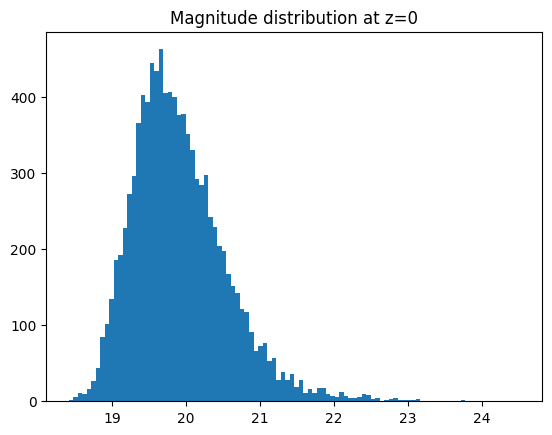

In [207]:
fil=['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y','subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484','subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679','subaru_suprimecam_ia738',
 'subaru_suprimecam_ia767','subaru_suprimecam_ip','subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J','vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']

import numpy as np
from sedpy.observate import load_filters, getSED

filters=load_filters(fil)
A = np.array(getSED(wave_grid, H, filters, linear_flux=True)*3631*1e6) 
flux=coeff_samples@A

m=23.9-2.5*np.log10(flux[:,2])
plt.hist(m,bins=100)
plt.title(f'Magnitude distribution at z={z}')
plt.show()

# Redshift dependant XD

In [13]:
import pandas as pd
df3 = pd.read_feather("cosmos_used_filter.feather")

In [14]:
df3

,X_IMAGE,Y_IMAGE,GALEX_NUV_FLUX,GALEX_FUV_FLUX,HSC_g_FLUX_APER2,HSC_r_FLUX_APER2,HSC_i_FLUX_APER2,HSC_z_FLUX_APER2,HSC_y_FLUX_APER2,SC_B_FLUX_APER2,...,SC_IA738_FLUX_APER2,SC_IA767_FLUX_APER2,SC_ip_FLUX_APER2,SC_zp_FLUX_APER2,SC_rp_FLUX_APER2,UVISTA_H_FLUX_APER2,UVISTA_J_FLUX_APER2,UVISTA_Y_FLUX_APER2,UVISTA_Ks_FLUX_APER2,ACS_F814W_FLUX
0,1304.953247,2579.132324,NaN,NaN,97.519783,229.977203,333.897583,491.040680,582.690369,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,818.016785,2725.062988,NaN,NaN,105.098213,118.250397,114.259003,179.894287,384.122742,0.037798,...,NaN,NaN,NaN,0.217983,0.060851,NaN,NaN,NaN,NaN,NaN
2,1324.814453,2583.007812,NaN,NaN,2.136770,4.961566,7.953316,9.829372,12.214380,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21610.509766,2415.219971,NaN,NaN,0.085408,0.071682,0.054122,0.022412,-0.000192,0.073336,...,NaN,NaN,NaN,-0.045704,0.126495,NaN,NaN,NaN,NaN,NaN
4,36540.632812,2414.936523,NaN,NaN,0.052692,0.043954,0.029368,0.124312,0.040235,0.110077,...,NaN,NaN,NaN,0.179530,0.106292,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1720695,47059.863281,42735.585938,NaN,NaN,0.017862,0.041047,0.079659,0.124605,0.170460,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1720696,47708.503906,42747.988281,NaN,NaN,NaN,NaN,0.000926,NaN,0.009624,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1720697,47446.062500,42748.003906,NaN,NaN,NaN,NaN,0.000158,NaN,0.024071,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1720698,47640.492188,42747.992188,NaN,NaN,NaN,NaN,0.001315,NaN,0.018937,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
import pandas as pd

# Your two DataFrames:
# df_flux: the one with only fluxes (currently loaded)
# df_err: the one that already contains the corresponding error columns

def convert_to_err_colname(colname):
    parts = colname.replace('FLUX','FLUXERR')
    return parts
    

# Create mapping from flux column → error column
col_mapping = {}
for col in df3.columns:
    err_col = convert_to_err_colname(col)
    if err_col in df.columns:
        col_mapping[col] = err_col

# Copy over matching error columns
for flux_col, err_col in col_mapping.items():
    df3[err_col] = df[err_col]

print(f"Copied {len(col_mapping)} error columns from df_err to df_flux.")


Copied 25 error columns from df_err to df_flux.


In [16]:
df3=df3.drop('X_IMAGE',axis=1)

In [17]:
df3.columns

Index(['Y_IMAGE', 'GALEX_NUV_FLUX', 'GALEX_FUV_FLUX', 'HSC_g_FLUX_APER2',
       'HSC_r_FLUX_APER2', 'HSC_i_FLUX_APER2', 'HSC_z_FLUX_APER2',
       'HSC_y_FLUX_APER2', 'SC_B_FLUX_APER2', 'SC_V_FLUX_APER2',
       'SC_IA484_FLUX_APER2', 'SC_IA527_FLUX_APER2', 'SC_IA624_FLUX_APER2',
       'SC_IA679_FLUX_APER2', 'SC_IA738_FLUX_APER2', 'SC_IA767_FLUX_APER2',
       'SC_ip_FLUX_APER2', 'SC_zp_FLUX_APER2', 'SC_rp_FLUX_APER2',
       'UVISTA_H_FLUX_APER2', 'UVISTA_J_FLUX_APER2', 'UVISTA_Y_FLUX_APER2',
       'UVISTA_Ks_FLUX_APER2', 'ACS_F814W_FLUX', 'GALEX_NUV_FLUXERR',
       'GALEX_FUV_FLUXERR', 'HSC_g_FLUXERR_APER2', 'HSC_r_FLUXERR_APER2',
       'HSC_i_FLUXERR_APER2', 'HSC_z_FLUXERR_APER2', 'HSC_y_FLUXERR_APER2',
       'SC_B_FLUXERR_APER2', 'SC_V_FLUXERR_APER2', 'SC_IA484_FLUXERR_APER2',
       'SC_IA527_FLUXERR_APER2', 'SC_IA624_FLUXERR_APER2',
       'SC_IA679_FLUXERR_APER2', 'SC_IA738_FLUXERR_APER2',
       'SC_IA767_FLUXERR_APER2', 'SC_ip_FLUXERR_APER2', 'SC_zp_FLUXERR_APER2',
     

In [1]:
import numpy as np
from sedpy.observate import getSED, load_filters

# -----------------------------
# Setup
# -----------------------------
fil = ['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y',
       'subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484',
       'subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679',
       'subaru_suprimecam_ia738','subaru_suprimecam_ia767','subaru_suprimecam_ip',
       'subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J',
       'vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']

filters = load_filters(fil)

# F_matrix: (M, Kc) where Kc = #PCA components
F_matrix = np.array([getSED(wave_grid, H_k, filters, linear_flux=True) * 3631 * 1e6
                     for H_k in H]).T  # (M, Kc)
FT = F_matrix.T  # (Kc, M)

# Photo-z mean and 1-sigma (Gaussian approx from 16–84th)
z = df['ez_z_phot'].to_numpy()
z_sigma = 0.5 * (df['ez_z840'] - df['ez_z160']).to_numpy()

# Mask bad/NaN redshifts
mask = np.isfinite(z) & np.isfinite(z_sigma) & (z_sigma > 0)
z = z[mask]
z_sigma = z_sigma[mask]

# Observed fluxes and errors (ensure these align to the same mask/order)
Y = np.nan_to_num(df3[df3.columns[:len(fil)]].to_numpy(float), nan=0.0)[mask]   # (N, M)
S = np.nan_to_num(df3[df3.columns[23:23+len(fil)]].to_numpy(float), nan=1e6)[mask]
R = S**2
N, M = Y.shape

# Latent dimensionalities
Kc = F_matrix.shape[1]  # coeffs
K  = Kc + 1             # coeffs + z  (last index is z)

# Prior initialization in the joint space [coeffs, z]
mean_prior = np.zeros(K)
cov_prior  = np.eye(K)
inv_cov_prior = np.linalg.inv(cov_prior)

# EM loop
num_iterations = 50
convergence_threshold = 1e-9
batch_size = 10000

print("--- XD (single-Gaussian) with noisy z ---")

for it in range(num_iterations):
    mu_old = mean_prior.copy()

    # Sufficient statistics in joint space
    sum_mean  = np.zeros(K)
    sum_cov   = np.zeros((K, K))
    sum_outer = np.zeros((K, K))

    for b in range(0, N, batch_size):
        i_end = min(b + batch_size, N)
        B = i_end - b

        Y_batch = Y[b:i_end]                   # (B, M)
        R_batch = R[b:i_end]                   # (B, M)
        z_batch = z[b:i_end]                   # (B,)
        zsig_b  = z_sigma[b:i_end]             # (B,)

        # Flux weights
        W   = 1.0 / R_batch                    # (B, M)
        W_Y = W * Y_batch                      # (B, M)

        # Redshift precision per object
        Wz = 1.0 / (zsig_b**2)                 # (B,)

        # ---- Build posterior precision A_i^{-1} per object in joint space ----
        # Start from prior precision
        A = np.broadcast_to(inv_cov_prior, (B, K, K)).copy()

        # Add flux term only to the coeff–coeff block: F^T W F
        # A_flux: (B, Kc, Kc)
        A_flux = np.einsum('km,bm,mj->bkj', FT, W, F_matrix)
        A[:, :Kc, :Kc] += A_flux

        # Add z_obs term only to the z–z entry
        A[:, Kc, Kc] += Wz

        # ---- Build RHS: Σ^{-1}μ + [F^T W Y; z_obs * Wz] ----
        rhs = np.tile((inv_cov_prior @ mean_prior)[None, :], (B, 1))  # (B, K)
        rhs[:, :Kc] += W_Y @ F_matrix                                  # coeff part (B, Kc)
        rhs[:,  Kc] += z_batch * Wz                                    # z part (B,)

        # Solve per object
        for i in range(B):
            Ai = A[i]
            rhsi = rhs[i]

            # Stabilize if needed
            # Ai += 1e-10 * np.eye(K)

            try:
                Ainv = np.linalg.inv(Ai)
            except np.linalg.LinAlgError:
                Ainv = np.linalg.pinv(Ai)

            x_post = Ainv @ rhsi   # posterior mean of [coeffs, z]
            sum_mean  += x_post
            sum_cov   += Ainv
            sum_outer += np.outer(x_post, x_post)

    # M-step: population mean/cov
    mean_prior = sum_mean / N
    cov_prior  = (sum_cov + sum_outer) / N - np.outer(mean_prior, mean_prior)

    # Recompute inverse (add a tiny jitter if needed)
    try:
        inv_cov_prior = np.linalg.inv(cov_prior)
    except np.linalg.LinAlgError:
        inv_cov_prior = np.linalg.pinv(cov_prior)

    delta_mu = np.linalg.norm(mean_prior - mu_old)
    print(f"Iter {it+1:02d} | Δμ = {delta_mu:.3e}")
    if delta_mu < convergence_threshold:
        break

print("\nFinal Prior Mean (coeffs..., z):\n", mean_prior)
print("\nFinal Prior Covariance (joint):\n", cov_prior)


C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename, resource_listdir


NameError: name 'H' is not defined

In [10]:
mean_prior= [ 3.23926777e-18 ,-1.68163283e-18,  1.18453195e-17 ,-3.17835860e-18,1.67621687e+00]
cov_prior=[[ 1.73417152e-32 ,-1.85997769e-32 , 2.01293673e-32, -6.26178023e-33,
   3.32216356e-17],
 [-1.85997769e-32 , 3.03084899e-32 ,-3.67523272e-32,  8.81601742e-33,
  -2.96931574e-17],
 [ 2.01293673e-32 ,-3.67523272e-32  ,1.28031670e-31 ,-7.80651275e-32,
   7.28858088e-17],
 [-6.26178023e-33  ,8.81601743e-33 ,-7.80651275e-32  ,6.32566018e-32,
  -3.71015919e-17],
 [ 3.32216356e-17 ,-2.96931574e-17  ,7.28858088e-17 ,-3.71015919e-17,
   3.64039914e+00]]

In [12]:
fil = ['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y',
       'subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484',
       'subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679',
       'subaru_suprimecam_ia738','subaru_suprimecam_ia767','subaru_suprimecam_ip',
       'subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J',
       'vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']

In [80]:
import numpy as np
from sedpy.observate import load_filters, getSED
filters = load_filters(fil)      # load all filters at once
A = np.array([
    getSED(wave_grid, H_k, filters, linear_flux=True) 
    for H_k in H
]).T   # shape → (n_bands, n_coeff)

A *= 3631 * 1e6

print(f"A.shape = {A.shape}")   # (n_bands, n_coeff)


A.shape = (23, 4)


C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:484: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10(counts / self.ab_zero_counts)


In [75]:
df1 = pd.read_feather("cosmos_used_filter.feather")


In [77]:
df1=df1.drop('X_IMAGE',axis=1)

In [78]:
z = df['ez_z_phot'].to_numpy()
z_sigma = 0.5 * (df['ez_z840'] - df['ez_z160']).to_numpy()

In [20]:
import numpy as np
mu = mean_prior # shape (n_coeff,) 
Sigma = cov_prior
# ----- Inputs -----
# A: (n_bands, n_coeff)
# mu_x: (n_coeff+1,)   # prior mean for [coeffs..., z]
# Sigma_x: (n_coeff+1, n_coeff+1)
# Y: (N_galaxies, n_bands)
# E: (N_galaxies, n_bands)
# z_obs: (N_galaxies,)
# z_sigma: (N_galaxies,)
Y = df1.to_numpy(float) 
Y = np.nan_to_num(Y, nan=0.0)  # (N_galaxies, n_bands)
E = df_err.to_numpy(float)  
E = np.nan_to_num(E, nan=1e6)  # (N_galaxies, n_bands)

# Compute 1/sigma^2 for each galaxy-band pair
W = 1.0 / (E**2)       

AT = A.T
Sigma_inv = np.linalg.inv(Sigma)

n_bands, n_coeff = A.shape
N = Y.shape[0]

coeffs_z = np.empty((N, n_coeff + 1))  # posterior mean [coeffs..., z]

for i in range(N):
    y = Y[i]
    e = E[i]
    z_i = z[i]
    sz_i = z_sigma[i]

    # Per-galaxy inverse noise weights
    W = 1.0 / (e**2)
    Rinv = np.diag(W)

    # ---- build block precision ----
    A_flux = AT @ (Rinv @ A)          # (n_coeff, n_coeff)
    rhs_flux = AT @ (Rinv @ y)        # (n_coeff,)

    # Joint precision and RHS
    A_joint = Sigma_inv.copy()
    A_joint[:n_coeff, :n_coeff] += A_flux
    A_joint[-1, -1] += 1.0 / (sz_i**2)

    rhs = Sigma_inv @ mu
    rhs[:n_coeff] += rhs_flux
    rhs[-1] += z_i / (sz_i**2)

    # ---- solve posterior mean ----
    try:
        C_post = np.linalg.inv(A_joint)
    except np.linalg.LinAlgError:
        C_post = np.linalg.pinv(A_joint)

    m_post = C_post @ rhs
    coeffs_z[i] = m_post

# coeffs_z[:, :-1] are the inferred PCA coefficients
# coeffs_z[:, -1]  are the inferred "true" redshifts


In [19]:
df_err = pd.read_feather("cosmos_used_error.feather")


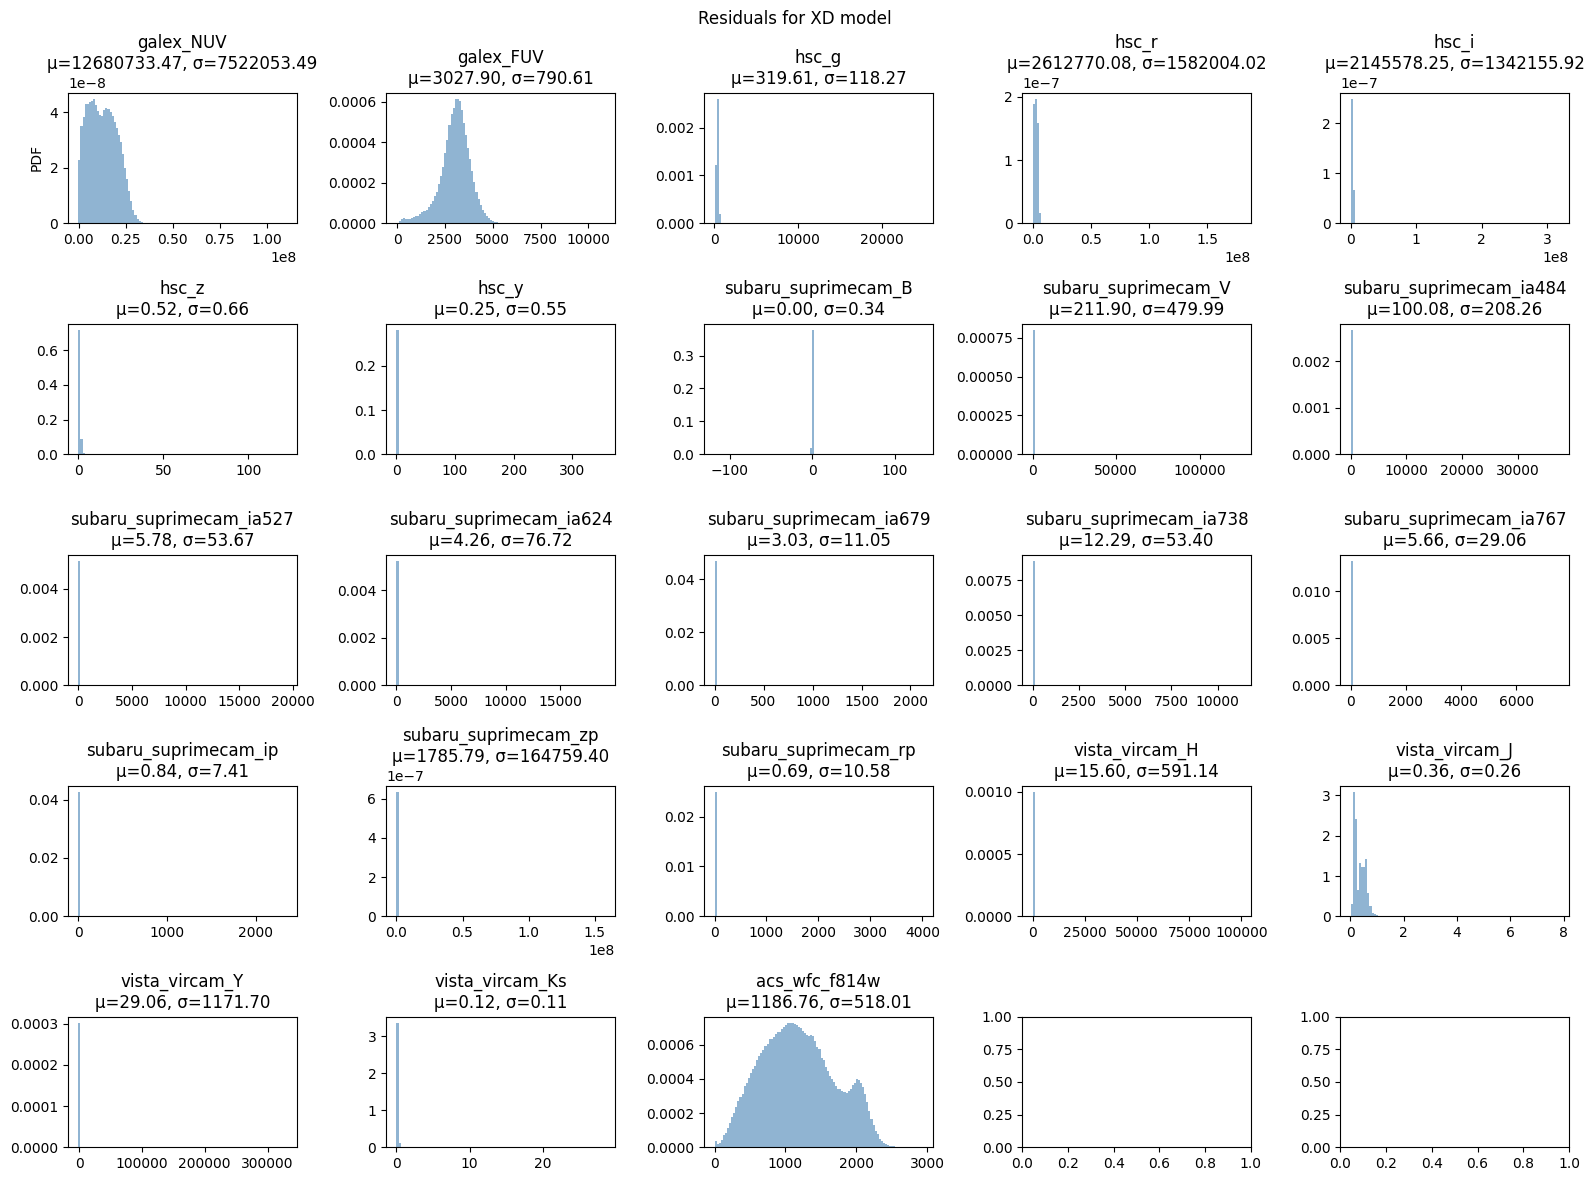

In [63]:
filt = load_filters(fil)
X = getSED(wave_grid, H, filt, linear_flux=True) * 3631 * 1e6 

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, axes = plt.subplots(5, 5, figsize=(16, 12))
axes = axes.flatten()

n_gal, n_bands = df.shape
wave1=[np.median(filt[i].wavelength) for i in range(len(filt))]
# Precompute once
  # (n_bands, n_coeff)
z = df['ez_z_phot'].to_numpy()
dL = df['ez_dL'].to_numpy() * 3.08e32  # Mpc → Å (3.08e24 cm, but since flux ∝ 1/dL^2, scaling constant cancels later)

# Compute denominator vectorized: shape (N,)
denom = (1 + z)**2 * 4 * np.pi * dL  # luminosity distance scaling

# Compute model fluxes in one vectorized shot
# coeffs_z[:, :4]: (N, 4)
# A[:4, :]: (4, n_bands)
# wave_eff: (n_bands,)
# denom[:, None]: (N, 1)
model_flux_all = (coeffs_z[:, :4] @ ( * wave_eff)) / denom[:, None]

for i in range(min(n_bands, df_err.shape[1])):  #
    data  = df.iloc[:, i].to_numpy()
    error = df_err.iloc[:, i].to_numpy()

    mask = np.isfinite(data) & np.isfinite(error) & np.isfinite(model_flux_all[:,0])
    data, error = data[mask], error[mask]
    model = model_flux_all[mask,i]

    # Normalized residuals
    r = (data - model) / error
    #r_clip = r[np.abs(r) < 2]

    ax = axes[i]
    ax.hist(r, bins=100, density=True, alpha=0.6, color='steelblue')

    mu, sd = np.mean(r), np.std(r)
    ax.set_title(f"{fil[i]}\nμ={mu:.2f}, σ={sd:.2f}")

axes[0].set_ylabel("PDF")
plt.suptitle('Residuals for XD model')
plt.tight_layout()
plt.show()


In [13]:
Y.shape

(1645765, 46)

# EM Algorithm

In [98]:
import numpy as np
import pandas as pd
from sedpy.observate import getSED, load_filters

# --------------------------------------------------------------------------
# This block is your data loading and setup code.
# You will need to replace the placeholder df and H generation with your actual data.
# --------------------------------------------------------------------------

# --- Setup Filters and PCA Basis ---
fil = ['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y',
       'subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484',
       'subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679',
       'subaru_suprimecam_ia738','subaru_suprimecam_ia767','subaru_suprimecam_ip',
       'subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J',
       'vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']
filters = load_filters(fil) # Assuming this is defined elsewhere

# For demonstration, creating placeholder data
N_galaxies = 10000
N_bands = len(fil)
Kc = 4 # Number of PCA components

# Create your PCA basis vectors `H`. Shape: (Kc, N_bands) -> (4, 23)
# >>> REPLACE this with your actual PCA components H and wave_grid. <<<

# F_matrix: This would be calculated using your getSED function
# For this demo, we'll create a placeholder projection matrix later.
F_matrix = np.array([getSED(wave_grid, H_k, filters, linear_flux=True) * 3631 * 1e6 for H_k in H]).T


# --------------------------------------------------------------------------
# Data Preparation
# --------------------------------------------------------------------------
print("--- Preparing Data ---")

# For the demo, create a simple projection matrix. You should use your F_matrix.
# This matrix projects from flux space to PCA coefficient space.
#projection_matrix = np.linalg.pinv(np.random.rand(N_bands, Kc)) # Placeholder
# In your code, this should be:
projection_matrix = np.linalg.pinv(F_matrix)

# Use photo-z mean as the predictor variable `z`
z = df['ez_z_phot'].to_numpy()
mask = np.isfinite(z) 
z = z[mask]

# Observed fluxes and errors (ensure these align to the same mask/order)
Y = np.nan_to_num(df3[df3.columns[:len(fil)]].to_numpy(float), nan=0.0)[mask]   # (N, M)
S = np.nan_to_num(df3[df3.columns[23:23+len(fil)]].to_numpy(float), nan=1e6)[mask]
R = S**2
N, M = Y.shape
assert M == len(fil)

# Pre-calculate observed PCA coefficients (W) and their covariances (S_w)
W_obs = np.zeros((N, Kc))
S_w = np.zeros((N, Kc, Kc))
for i in range(N):
    W_obs[i] = projection_matrix @ Y[i]
    S_flux_i = np.diag(R[i])
    S_w[i] = projection_matrix @ S_flux_i @ projection_matrix.T

# --------------------------------------------------------------------------
# Redshift-Dependent EM Algorithm
# --------------------------------------------------------------------------

# Initialization for the model parameters μ(z) = M0 + M1*z
M0 = np.mean(W_obs, axis=0)
M1 = np.zeros(Kc)
Sigma = np.cov(W_obs, rowvar=False)

# EM loop settings
num_iterations = 50
convergence_threshold = 1e-17
batch_size = 5000

print("\n--- EM for Redshift-Dependent Mean (p(coeffs|z)) ---")

for it in range(num_iterations):
    M0_old, M1_old = M0.copy(), M1.copy()

    # --- Initialize Sufficient Statistics for the M-step ---
    # For the linear regression part (M0, M1 update)
    sum_b = np.zeros(Kc)
    sum_zb = np.zeros(Kc)
    
    # For the Sigma update part
    sum_B = np.zeros((Kc, Kc))
    sum_b_outer = np.zeros((Kc, Kc))

    for b_idx in range(0, N, batch_size):
        i_end = min(b_idx + batch_size, N)
        B_size = i_end - b_idx

        # Get batches of pre-calculated data
        W_batch = W_obs[b_idx:i_end]
        Sw_batch = S_w[b_idx:i_end]
        z_batch = z[b_idx:i_end]

        # --- E-Step for the current batch ---
        # Calculate posterior mean (b_i) and covariance (B_i) for each object
        for i in range(B_size):
            wi = W_batch[i]
            Si = Sw_batch[i]
            zi = z_batch[i]

            mu_i = M0 + M1 * zi
            try:
                sig_i = np.linalg.inv(Sigma) 
                s_i = np.linalg.inv(Si)
    
                # Posterior mean b_i = E[v_i | w_i, z_i, θ]
                Bi = np.linalg.inv(sig_i + s_i) 
            except:
                sig_i = np.linalg.pinv(Sigma) 
                s_i = np.linalg.pinv(Si)
    
                # Posterior mean b_i = E[v_i | w_i, z_i, θ]
                Bi = np.linalg.pinv(sig_i + s_i)       # posterior covariance
            bi = Bi @ (sig_i @ mu_i + s_i @ wi)   

            # --- Accumulate sufficient statistics ---
            sum_b += bi
            sum_zb += zi * bi
            sum_B += Bi
            sum_b_outer += np.outer(bi, bi)

    # --- M-Step: Update parameters using accumulated statistics ---
    
    # 1. Update M0 and M1
    # Solve the 2x2 system for each of the Kc dimensions
    sum_z = np.sum(z)
    sum_z2 = np.sum(z**2)
    A_reg = np.array([[N, sum_z], [sum_z, sum_z2]])
    A_reg_inv = np.linalg.inv(A_reg)
    
    rhs = np.vstack([sum_b, sum_zb]) # Shape (2, Kc)
    M0, M1 = A_reg_inv @ rhs         # Shape (2, Kc)
    mu_new=M0
    # 2. Update Sigma
    # Sigma_new = (1/N) * Σ [ B_i + E[(v_i - μ_new_i)(v_i - μ_new_i)^T] ]
    # which expands to using the sufficient statistics.
    mu_b_outer = np.outer(M0, sum_b) + np.outer(M1, sum_zb)
    mu_mu_outer = N * np.outer(M0, M0) + sum_z * (np.outer(M0, M1) + np.outer(M1, M0)) + sum_z2 * np.outer(M1, M1)
    
    Sigma = (sum_B + sum_b_outer - mu_b_outer - mu_b_outer.T + mu_mu_outer) / N

    # --- Convergence Check ---
    delta_M = np.linalg.norm(M0 - M0_old) + np.linalg.norm(M1 - M1_old)
    print(f"Iter {it+1:02d} | ΔM = {delta_M:.3e}")
    if delta_M < convergence_threshold:
        print("Convergence threshold reached.")
        break

print("\n--- Fit Complete ---")
print("\nFinal M0 (mean at z=0):\n", M0)
print("\nFinal M1 (redshift evolution of mean):\n", M1)
print("\nFinal Sigma (intrinsic covariance of coeffs):\n", Sigma)

--- Preparing Data ---

--- EM for Redshift-Dependent Mean (p(coeffs|z)) ---
Iter 01 | ΔM = 1.611e-16
Iter 02 | ΔM = 7.289e-17
Iter 03 | ΔM = 3.552e-17
Iter 04 | ΔM = 1.877e-17
Iter 05 | ΔM = 1.083e-17
Iter 06 | ΔM = 6.944e-18
Convergence threshold reached.

--- Fit Complete ---

Final M0 (mean at z=0):
 [ 7.92611020e-19  3.72214622e-17 -1.53056231e-16  5.62150603e-17]

Final M1 (redshift evolution of mean):
 [-9.78495984e-19 -2.14220415e-17  1.06085033e-16 -3.69450946e-17]

Final Sigma (intrinsic covariance of coeffs):
 [[ 1.82300951e-31  2.79451546e-31 -2.64234156e-31 -6.14397061e-31]
 [ 2.79451538e-31  6.71692835e-31 -1.31342012e-30 -5.21204915e-31]
 [-2.64234120e-31 -1.31342007e-30  4.50272828e-30 -1.22190662e-30]
 [-6.14397083e-31 -5.21204980e-31 -1.22190645e-30  3.31344484e-30]]


In [67]:
M0=[ 7.92611020e-19,3.72214622e-17, -1.53056231e-16 , 5.62150603e-17]
M1=[-9.78495984e-19 ,-2.14220415e-17 , 1.06085033e-16, -3.69450946e-17]
Sigma=[[ 1.82300951e-31 , 2.79451546e-31 ,-2.64234156e-31 ,-6.14397061e-31],
 [ 2.79451538e-31 , 6.71692835e-31 ,-1.31342012e-30, -5.21204915e-31],
 [-2.64234120e-31 ,-1.31342007e-30 , 4.50272828e-30 ,-1.22190662e-30],
 [-6.14397083e-31 ,-5.21204980e-31 ,-1.22190645e-30  ,3.31344484e-30]]

In [93]:
import numpy as np

mu = np.add(M0,np.add(M1, M1)) # shape (n_coeff,) 
# ----- Inputs -----
# A: (n_bands, n_coeff)
# mu_x: (n_coeff+1,)   # prior mean for [coeffs..., z]
# Sigma_x: (n_coeff+1, n_coeff+1)
# Y: (N_galaxies, n_bands)
# E: (N_galaxies, n_bands)
# z_obs: (N_galaxies,)
# z_sigma: (N_galaxies,)
Y = df1.to_numpy(float) 
Y = np.nan_to_num(Y, nan=0.0)  # (N_galaxies, n_bands)
E = df_err.to_numpy(float)  
E = np.nan_to_num(E, nan=1e6)  # (N_galaxies, n_bands)

# Compute 1/sigma^2 for each galaxy-band pair
W = 1.0 / (E**2)       

AT = A.T
Sigma_inv = np.linalg.inv(Sigma)

n_bands, n_coeff = A.shape
N = Y.shape[0]

coeffs_z_2 = np.empty((N, n_coeff + 1))  # posterior mean [coeffs..., z]

for i in range(N):
    y = Y[i]
    e = E[i]
    z_i = z[i]
    sz_i = z_sigma[i]

    # Per-galaxy inverse noise weights
    W = 1.0 / (e**2)
    Rinv = np.diag(W)

    # ---- build block precision ----
    A_flux = AT @ (Rinv @ A)          # (n_coeff, n_coeff)
    rhs_flux = AT @ (Rinv @ y)        # (n_coeff,)

    # Joint precision and RHS
    A_joint = Sigma_inv.copy()
    A_joint[:n_coeff, :n_coeff] += A_flux
    A_joint[-1, -1] += 1.0 / (sz_i**2)

    rhs = Sigma_inv @ mu
    rhs[:n_coeff] += rhs_flux
    rhs[-1] += z_i / (sz_i**2)

    # ---- solve posterior mean ----
    try:
        C_post = np.linalg.inv(A_joint)
    except np.linalg.LinAlgError:
        C_post = np.linalg.pinv(A_joint)

    m_post = C_post @ rhs
    coeffs_z_2[i] = m_post

# coeffs_z[:, :-1] are the inferred PCA coefficients
# coeffs_z[:, -1]  are the inferred "true" redshifts


ValueError: could not broadcast input array from shape (4,) into shape (5,)

In [94]:
filt = load_filters(fil)
X = getSED(wave_grid, H, filt, linear_flux=True) * 3631 * 1e6 

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, axes = plt.subplots(5, 5, figsize=(16, 12))
axes = axes.flatten()

n_gal, n_bands = df.shape
wave1=[np.median(filt[i].wavelength) for i in range(len(filt))]
# Precompute once
  # (n_bands, n_coeff)
z = df['ez_z_phot'].to_numpy()
dL = df['ez_dL'].to_numpy() * 3.08e32  # Mpc → Å (3.08e24 cm, but since flux ∝ 1/dL^2, scaling constant cancels later)

# Compute denominator vectorized: shape (N,)
denom = (1 + z)**2 * 4 * np.pi * dL  # luminosity distance scaling

# Compute model fluxes in one vectorized shot
# coeffs_z[:, :4]: (N, 4)
# A[:4, :]: (4, n_bands)
# wave_eff: (n_bands,)
# denom[:, None]: (N, 1)
model_flux_all = (coeffs_z[:, :4] @ (X * wave_eff)) / denom[:, None]

for i in range(min(n_bands, df_err.shape[1])):  #
    data  = df.iloc[:, i].to_numpy()
    error = df_err.iloc[:, i].to_numpy()

    mask = np.isfinite(data) & np.isfinite(error) & np.isfinite(model_flux_all[:,0])
    data, error = data[mask], error[mask]
    model = model_flux_all[mask,i]

    # Normalized residuals
    r = (data - model) / error
    #r_clip = r[np.abs(r) < 2]

    ax = axes[i]
    ax.hist(r, bins=100, density=True, alpha=0.6, color='steelblue')

    mu, sd = np.mean(r), np.std(r)
    ax.set_title(f"{fil[i]}\nμ={mu:.2f}, σ={sd:.2f}")

axes[0].set_ylabel("PDF")
plt.suptitle('Residuals for XD model')
plt.tight_layout()
plt.show()


(4, 4)

In [ ]:
import numpy as np
import pandas as pd
from sedpy.observate import getSED, load_filters

# --------------------------------------------------------------------------
# This block is your data loading and setup code.
# You will need to replace the placeholder df and H generation with your actual data.
# --------------------------------------------------------------------------
f_all = np.load('pcaflux_w_redshift.npy')
f=[]
for i in range(len(z_grid1)):
    f.append(f_all[i])
f_interp = interp1d(z_grid1, f, axis=0)
# --- Setup Filters and PCA Basis ---
fil = ['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y',
       'subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484',
       'subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679',
       'subaru_suprimecam_ia738','subaru_suprimecam_ia767','subaru_suprimecam_ip',
       'subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J',
       'vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']
filters = load_filters(fil) # Assuming this is defined elsewhere

# For demonstration, creating placeholder data
N_galaxies = 10000
N_bands = len(fil)
Kc = 4 # Number of PCA components

# Create your PCA basis vectors `H`. Shape: (Kc, N_bands) -> (4, 23)
# >>> REPLACE this with your actual PCA components H and wave_grid. <<<

# F_matrix: This would be calculated using your getSED function
# For this demo, we'll create a placeholder projection matrix later.
#F_matrix = np.array([getSED(wave_grid, H_k, filters, linear_flux=True) * 3631 * 1e6 for H_k in H]).T


# --------------------------------------------------------------------------
# Data Preparation
# --------------------------------------------------------------------------
print("--- Preparing Data ---")

# For the demo, create a simple projection matrix. You should use your F_matrix.
# This matrix projects from flux space to PCA coefficient space.
#projection_matrix = np.linalg.pinv(np.random.rand(N_bands, Kc)) # Placeholder
# In your code, this should be:
#projection_matrix = np.linalg.pinv(F_matrix)

# Use photo-z mean as the predictor variable `z`
z = df['ez_z_phot'].to_numpy()
mask = np.isfinite(z) 
z = z[mask]

# Observed fluxes and errors (ensure these align to the same mask/order)
Y = np.nan_to_num(df3[df3.columns[:len(fil)]].to_numpy(float), nan=0.0)[mask]   # (N, M)
S = np.nan_to_num(df3[df3.columns[23:23+len(fil)]].to_numpy(float), nan=1e6)[mask]
R = S**2
N, M = Y.shape
assert M == len(fil)

# Pre-calculate observed PCA coefficients (W) and their covariances (S_w)
W_obs = np.zeros((N, Kc))
S_w = np.zeros((N, Kc, Kc))
for i in range(N):
    W_obs[i] = projection_matrix @ Y[i]
    S_flux_i = np.diag(R[i])
    S_w[i] = projection_matrix @ S_flux_i @ projection_matrix.T

# --------------------------------------------------------------------------
# Redshift-Dependent EM Algorithm
# --------------------------------------------------------------------------

# Initialization for the model parameters μ(z) = M0 + M1*z
M0 = np.mean(W_obs, axis=0)
M1 = np.zeros(Kc)
Sigma = np.cov(W_obs, rowvar=False)

# EM loop settings
num_iterations = 50
convergence_threshold = 1e-17
batch_size = 5000

print("\n--- EM for Redshift-Dependent Mean (p(coeffs|z)) ---")

for it in range(num_iterations):
    M0_old, M1_old = M0.copy(), M1.copy()

    # --- Initialize Sufficient Statistics for the M-step ---
    # For the linear regression part (M0, M1 update)
    sum_b = np.zeros(Kc)
    sum_zb = np.zeros(Kc)
    
    # For the Sigma update part
    sum_B = np.zeros((Kc, Kc))
    sum_b_outer = np.zeros((Kc, Kc))

    for b_idx in range(0, N, batch_size):
        i_end = min(b_idx + batch_size, N)
        B_size = i_end - b_idx

        # Get batches of pre-calculated data
        Y_batch = Y[b_idx:i_end]                   # (B, M)
        R_batch = R[b_idx:i_end]                   # (B, M)
        z_batch = z[b_idx:i_end]                   # (B,)
        zsig_b  = z_sigma[b_idx:i_end]

        # --- E-Step for the current batch ---
        # Calculate posterior mean (b_i) and covariance (B_i) for each object
        for i in range(B_size):
            
            zi = z_batch[i]

            mu_i = M0 + M1 * zi
            try:
                sig_i = np.linalg.inv(Sigma) 
                Fz=f_interp(zi)
                
                # Posterior mean b_i = E[v_i | w_i, z_i, θ]
                Bi = np.linalg.inv(sig_i + s_i) 
            except:
                sig_i = np.linalg.pinv(Sigma) 
                Bi = np.linalg.pinv(sig_i + s_i)       # posterior covariance
            
            bi = Bi @ (sig_i @ mu_i + s_i @ wi)   

            # --- Accumulate sufficient statistics ---
            sum_b += bi
            sum_zb += zi * bi
            sum_B += Bi
            sum_b_outer += np.outer(bi, bi)

    # --- M-Step: Update parameters using accumulated statistics ---
    
    # 1. Update M0 and M1
    # Solve the 2x2 system for each of the Kc dimensions
    sum_z = np.sum(z)
    sum_z2 = np.sum(z**2)
    A_reg = np.array([[N, sum_z], [sum_z, sum_z2]])
    A_reg_inv = np.linalg.inv(A_reg)
    
    rhs = np.vstack([sum_b, sum_zb]) # Shape (2, Kc)
    M0, M1 = A_reg_inv @ rhs         # Shape (2, Kc)
    mu_new=M0
    # 2. Update Sigma
    # Sigma_new = (1/N) * Σ [ B_i + E[(v_i - μ_new_i)(v_i - μ_new_i)^T] ]
    # which expands to using the sufficient statistics.
    mu_b_outer = np.outer(M0, sum_b) + np.outer(M1, sum_zb)
    mu_mu_outer = N * np.outer(M0, M0) + sum_z * (np.outer(M0, M1) + np.outer(M1, M0)) + sum_z2 * np.outer(M1, M1)
    
    Sigma = (sum_B + sum_b_outer - mu_b_outer - mu_b_outer.T + mu_mu_outer) / N

    # --- Convergence Check ---
    delta_M = np.linalg.norm(M0 - M0_old) + np.linalg.norm(M1 - M1_old)
    print(f"Iter {it+1:02d} | ΔM = {delta_M:.3e}")
    if delta_M < convergence_threshold:
        print("Convergence threshold reached.")
        break

print("\n--- Fit Complete ---")
print("\nFinal M0 (mean at z=0):\n", M0)
print("\nFinal M1 (redshift evolution of mean):\n", M1)
print("\nFinal Sigma (intrinsic covariance of coeffs):\n", Sigma)

# Final Algorithm

In [5]:
f_all = np.load('pcaflux_w_redshift.npy')

In [39]:
f=[]
for i in range(len(z_grid1)):
    f.append(f_all[i])

In [72]:
import numpy as np
from scipy.interpolate import interp1d

# -----------------------------------------------------------
# --- Inputs (replace placeholders with your real data) ---
# ----------------------------/-------------------------------

# f_all: (Nz, M, Kc) array of redshifted PCA component fluxes
# z_grid: (Nz,) array of redshift grid points
# df, df3: your galaxy flux + error dataframes
# M = number of filters, Kc = number of PCA components

fil = ['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y',
       'subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484',
       'subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679',
       'subaru_suprimecam_ia738','subaru_suprimecam_ia767','subaru_suprimecam_ip',
       'subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J',
       'vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']

Nz, Kc,M = f_all.shape

# --- Observed data ---
z_obs = df['ez_z_phot'].to_numpy()
z_sigma = 0.5 * (df['ez_z840'] - df['ez_z160']).to_numpy()
mask = np.isfinite(z_obs) & np.isfinite(z_sigma) & (z_sigma > 0)
z_obs, z_sigma = z_obs[mask], z_sigma[mask]

Y = np.nan_to_num(df3[df3.columns[:M]].to_numpy(float), nan=0.0)[mask]    # fluxes
S = np.nan_to_num(df3[df3.columns[M:M*2]].to_numpy(float), nan=1e6)[mask] # errors
R = S**2
N = len(z_obs)

# -----------------------------------------------------------
# --- Initialization ---
# -----------------------------------------------------------
M0 = np.random.normal(0, 1e-3, Kc)
M1 = np.random.normal(0, 1e-3, Kc)
Sigma = np.eye(Kc)
z_post_prev = z_obs.copy()
f_interp = interp1d(z_grid1, f, axis=0)
num_iterations = 50
batch_size = 2000
convergence_threshold = 1e-28

print("\n--- Hybrid EM (XD-style E-step + Linear M-step) ---\n")

# -----------------------------------------------------------
# --- EM Loop ---
# -----------------------------------------------------------
for it in range(num_iterations):
    M0_old, M1_old = M0.copy(), M1.copy()
    Sigma_inv = np.linalg.inv(Sigma)

    # Sufficient statistics
    sum_b, sum_zb = np.zeros(Kc), np.zeros(Kc)
    sum_B = np.zeros((Kc, Kc))
    sum_b_outer = np.zeros((Kc, Kc))
    sum_z, sum_z2 = 0.0, 0.0

    for b in range(0, N, batch_size):
        i_end = min(b + batch_size, N)
        B = i_end - b

        Y_batch = Y[b:i_end]
        R_batch = R[b:i_end]
        zobs_batch = z_obs[b:i_end]
        zsig_batch = z_sigma[b:i_end]
        zprev_batch = z_post_prev[b:i_end]

        for i in range(B):
            yi = Y_batch[i]
            Si_inv = np.diag(1.0 / R_batch[i])
            zobs = zobs_batch[i]
            sigz = zsig_batch[i]
            z_now = zprev_batch[i] if it > 0 else zobs

            Fi=f_interp(z_now).T
            # --- Build posterior precision matrix A_i ---
            A_vv = Sigma_inv + Fi.T @ Si_inv @ Fi
            A_vz = -Sigma_inv @ M1[:, None] 
            A_zv = A_vz.T
            A_zz = (M1.T @ Sigma_inv @ M1) + 1.0 / sigz**2

            A_i = np.block([
                [A_vv, A_vz],
                [A_zv, A_zz]
            ])

            # --- Build RHS b_i ---
            b_v = (Sigma_inv @ M0 + Fi.T @ Si_inv @ yi)[:, None]   # (Kc,1)
            b_z = np.array([[ (zobs / sigz**2) + (M1 @ (Sigma_inv @ M0)) ]])  # (1,1)
            b_i = np.vstack([b_v, b_z])  

            # --- Solve for posterior mean ---
            try:
                A_inv = np.linalg.inv(A_i)
            except np.linalg.LinAlgError:
                A_inv = np.linalg.pinv(A_i)

            x_post = A_inv @ b_i
            v_post = x_post[:-1, 0]                                # (Kc,)
            z_post = float(x_post[-1, 0])
            B_post = A_inv[:-1, :-1] # cov of coeffs

            # --- Accumulate sufficient statistics ---
            sum_b += v_post
            sum_zb += z_post * v_post
            sum_B += B_post
            sum_b_outer += np.outer(v_post, v_post)
            sum_z += z_post
            sum_z2 += z_post**2 + A_inv[-1, -1]

            # Store posterior z for next iteration
            z_post_prev[b + i] = z_post

    # --- M-step ---
    
    A_reg = np.array([[N, sum_z], [sum_z, sum_z2]])
    rhs = np.vstack([sum_b, sum_zb])
    M0, M1 = np.linalg.inv(A_reg) @ rhs

    # Update Sigma
    Sigma = (sum_B + sum_b_outer) / N - np.outer(M0, M0) - \
            (sum_z/N)*(np.outer(M0, M1) + np.outer(M1, M0)) - \
            (sum_z2/N)*np.outer(M1, M1)

    

    # Convergence
    delta = np.linalg.norm(M0 - M0_old) + np.linalg.norm(M1 - M1_old)
    print(f"Iter {it+1:02d} | ΔM = {delta:.3e}")
    if delta < convergence_threshold:
        print("Converged.")
        break

print("\n--- Fit Complete ---")
print("Final M0 (mean at z=0):", M0)
print("Final M1 (redshift slope):", M1)
print("Final Sigma (intrinsic covariance):\n", Sigma)



--- Hybrid EM (XD-style E-step + Linear M-step) ---

Iter 01 | ΔM = 3.614e-04
Iter 02 | ΔM = 3.280e-04
Iter 03 | ΔM = 2.976e-04
Iter 04 | ΔM = 2.700e-04
Iter 05 | ΔM = 2.448e-04
Iter 06 | ΔM = 2.219e-04
Iter 07 | ΔM = 2.010e-04
Iter 08 | ΔM = 1.820e-04


KeyboardInterrupt: 

In [75]:
M1_old

array([9.96714102e-05, 7.01577491e-04, 1.44663996e-04, 2.93229037e-04])

In [55]:
zprev_batch[i]

-67108864.0